In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rc

In [2]:
#Cosmetic parameters
font = {'size': 16, 'family': 'STIXGeneral'}
matplotlib.rc('font', **font)
rc('font', family='serif')
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['figure.dpi'] = 300
rc("axes", linewidth=2.0)
rc("lines", markeredgewidth=4)
rc('xtick', labelsize=20)
rc('ytick', labelsize=20)

fig_width_pt = 703.27  # Get this from LaTeX using \showthe\columnwidth
inches_per_pt = 1.0 / 72.27  # Convert pt to inches
golden_mean = 1.0 
fig_width = fig_width_pt * inches_per_pt # width in inches
fig_height = fig_width * golden_mean # height in inches
fig_size = [fig_width, fig_height]

params = {
    'backend': 'pdf',
    'axes.labelsize': 14,
    'lines.markersize': 4,
    'font.size': 10,
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'lines.markeredgewidth': 1,
    'axes.linewidth': 1.2,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'savefig.dpi': 300,
    'figure.figsize': fig_size,
#      ‘path.simplify’:True,
#      ‘font.family’: ‘serif’,
#      ‘font.serif’:‘Times’,
    'text.usetex': True,
    # 'text.latex.preamble': [r'\usepackage{amsmath}'],
}

plt.rcParams.update(params)

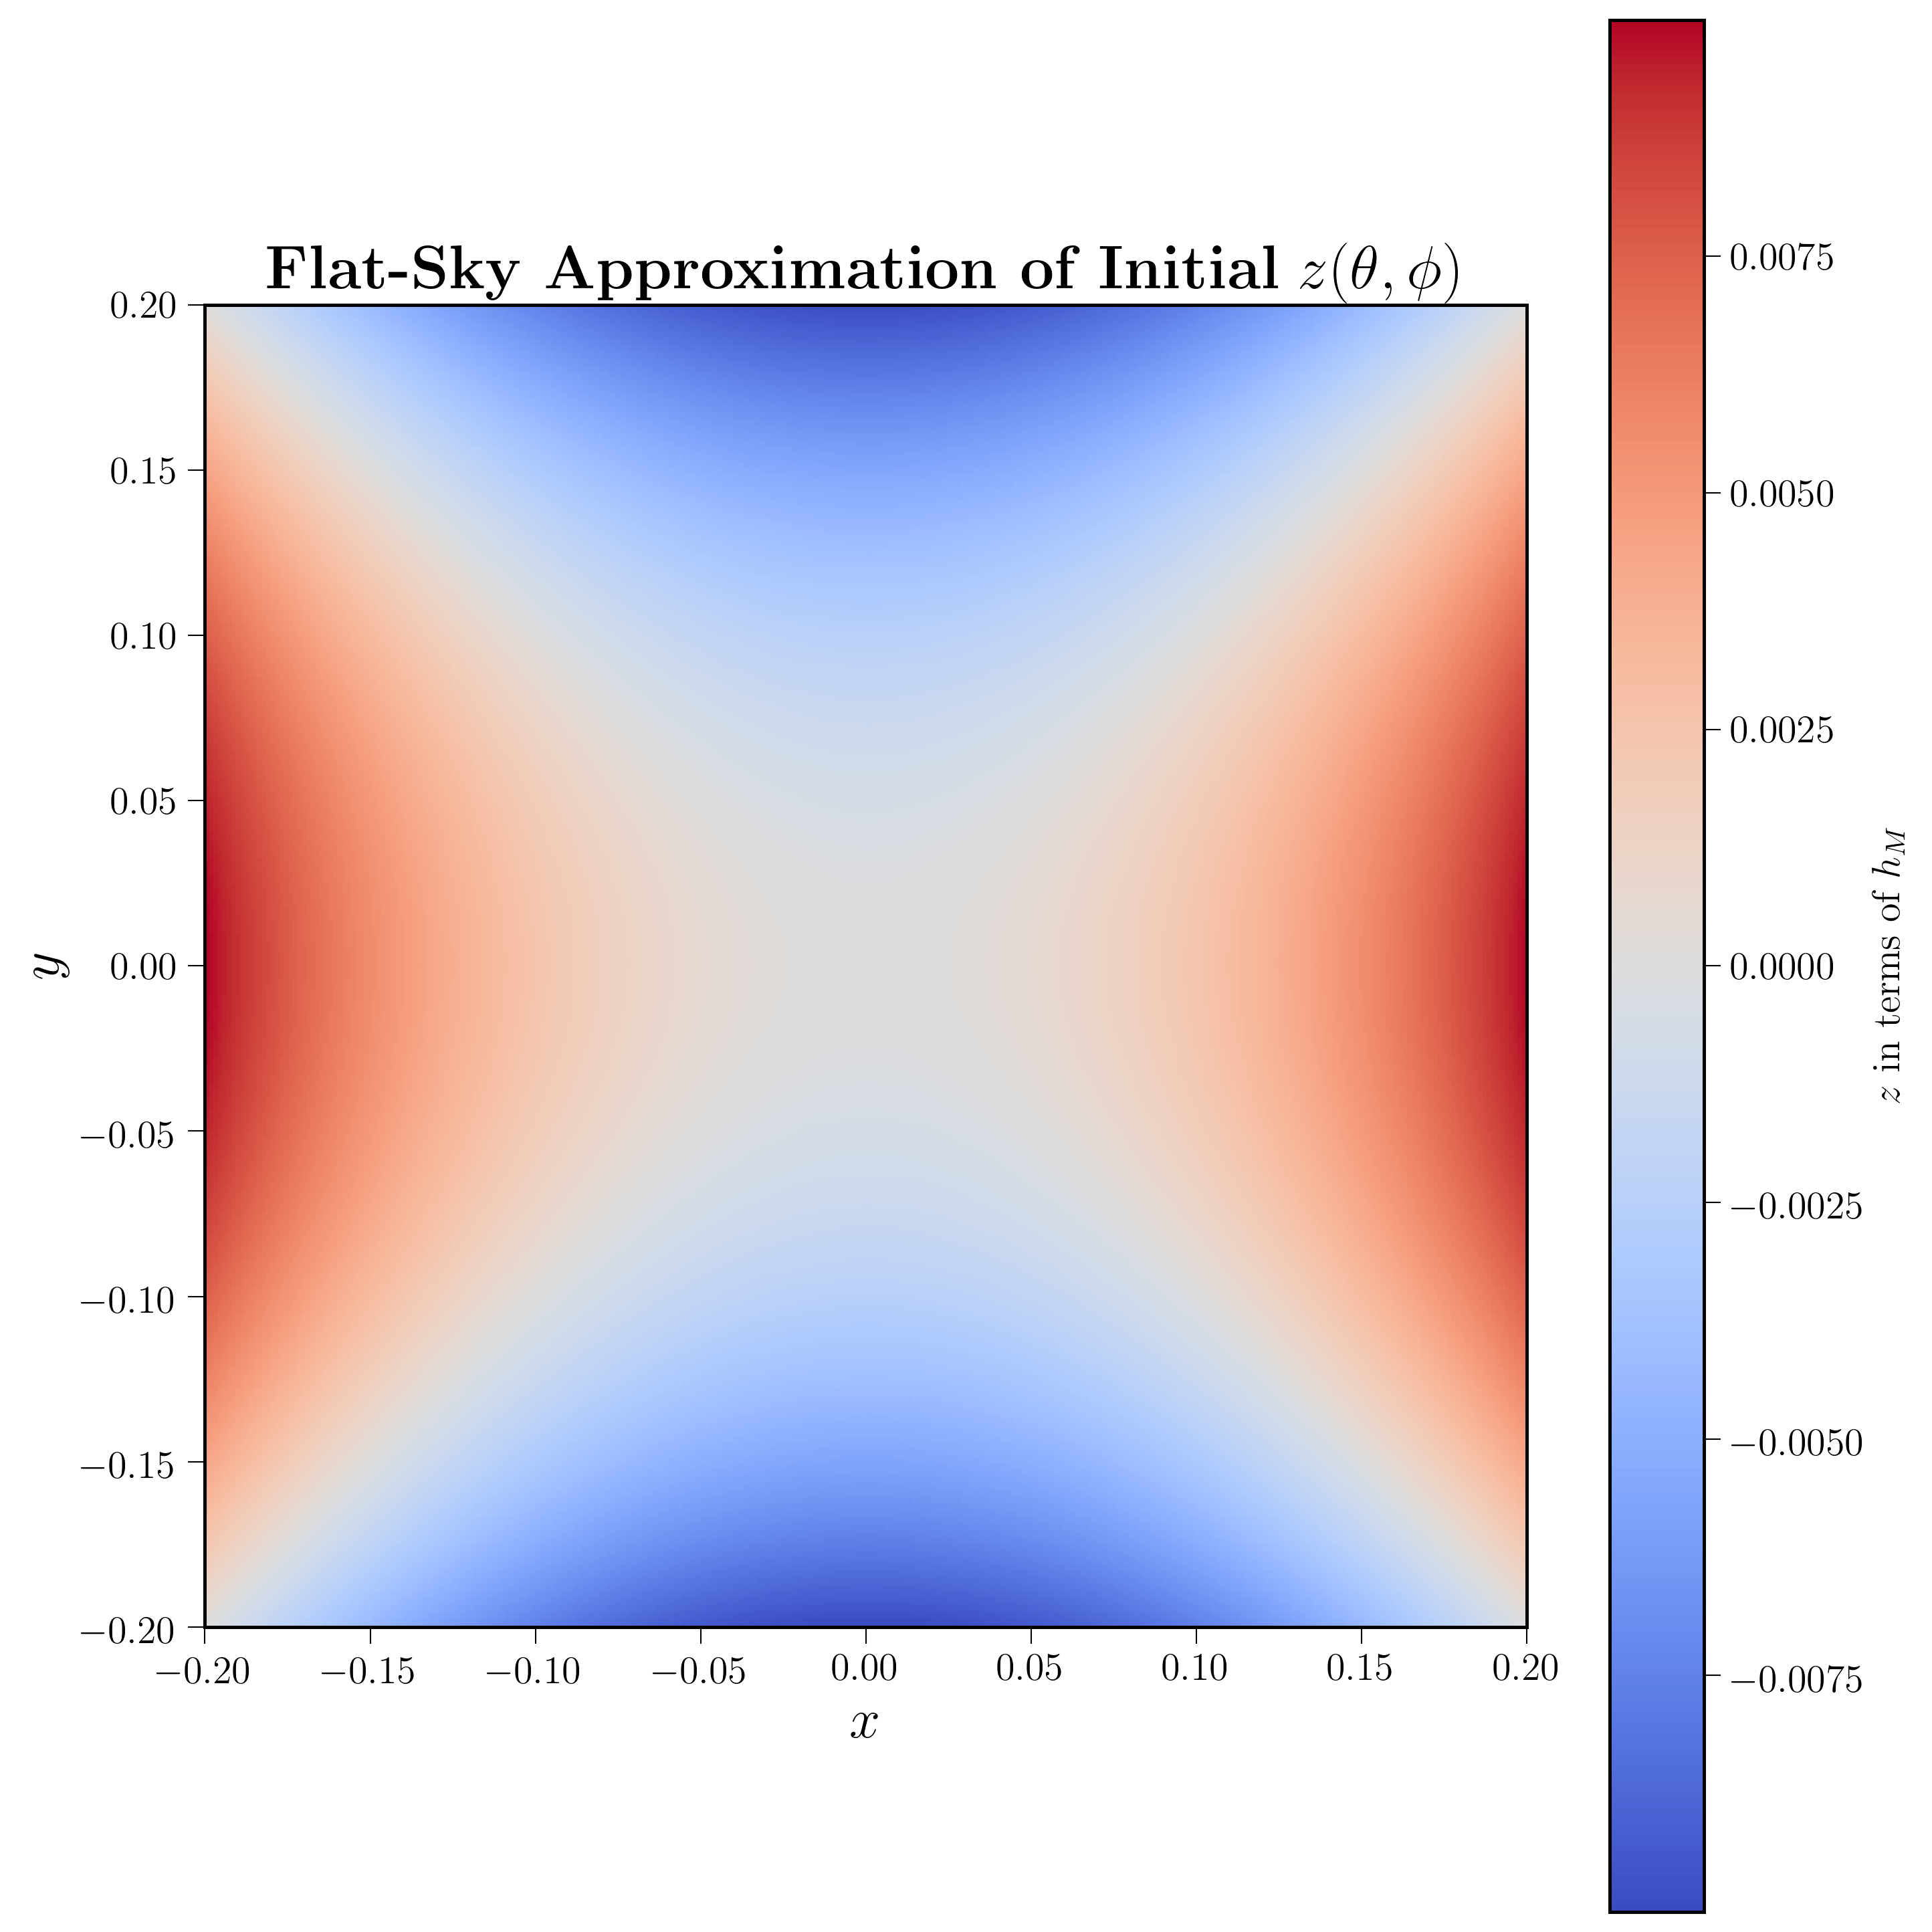

In [3]:
# Plotting initial redshift equation from Madison's paper 
# Madison's equation also has a cutoff angle above which z=0

# Create a small grid around (0,0)
r_max = 0.2  # in radians, small for flat approximation
N = 300
x = np.linspace(-r_max, r_max, N)
y = np.linspace(-r_max, r_max, N)
X, Y = np.meshgrid(x, y)

# Convert x/y to polar coordinates
theta = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

# Calculate z at each point
Z = (theta**2 / 4) * np.cos(2 * phi)

# Plot
fig, ax = plt.subplots()
c = ax.pcolormesh(X, Y, Z, shading='auto', cmap='coolwarm')
c = ax.pcolormesh(X, Y, Z, shading='auto', cmap='coolwarm')
fig.colorbar(c, ax=ax, label=r'$z$ in terms of $h_M$')
ax.set_xlabel(r'$x$', fontsize=20)
ax.set_ylabel(r'$y$', fontsize=20)
ax.set_title(r'\textbf{Flat-Sky Approximation of Initial} $z(\theta, \phi)$', fontsize=22)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

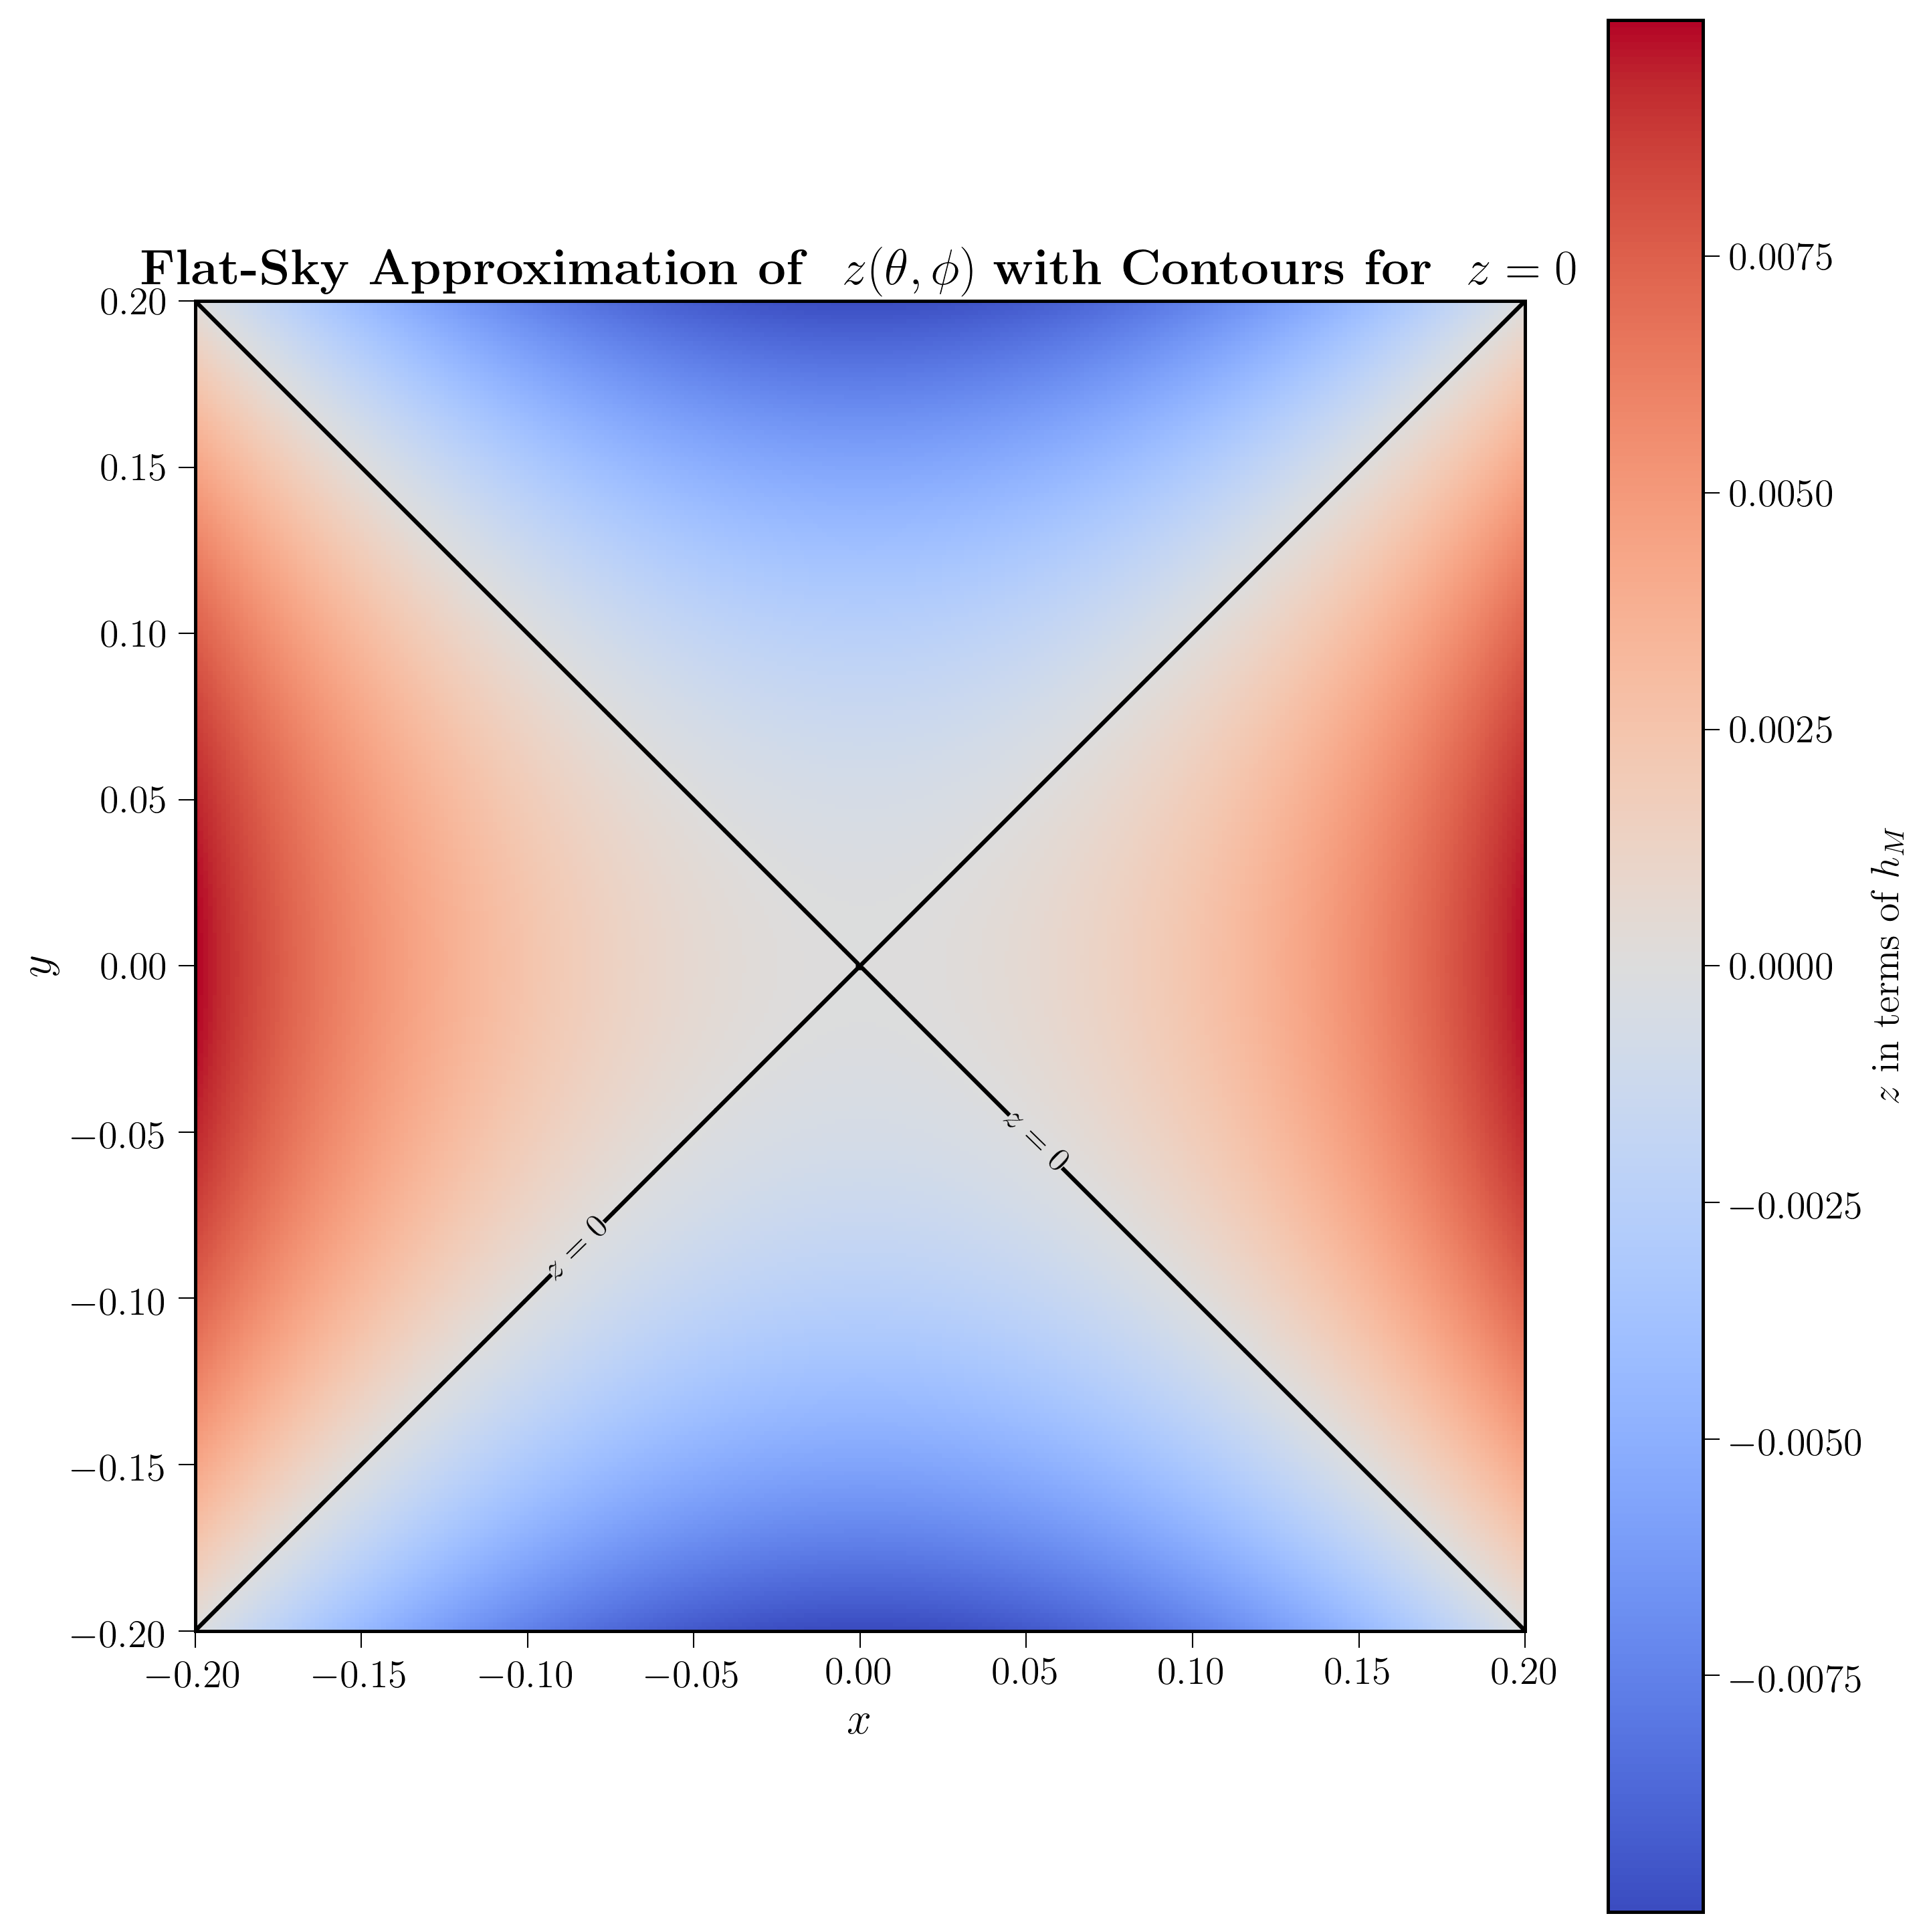

In [4]:
# Same redshift plot, but with contours showing where z is 0
fig, ax = plt.subplots()
c = ax.pcolormesh(X, Y, Z, shading='auto', cmap='coolwarm')

# Add contour where Z = 0
contour = ax.contour(X, Y, Z, levels=[0], colors='k', linewidths=1.5)
ax.clabel(contour, fmt={0: r'$z=0$'}, inline=True, fontsize=12)

# Colorbar and labels
fig.colorbar(c, ax=ax, label=r'$z$ in terms of $h_M$')
ax.set_xlabel(r'$x$', fontsize=16)
ax.set_ylabel(r'$y$', fontsize=16)
ax.set_title(r'\textbf{Flat-Sky Approximation of } $z(\theta, \phi)$ \textbf{with Contours for } $z=0$', fontsize=18)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


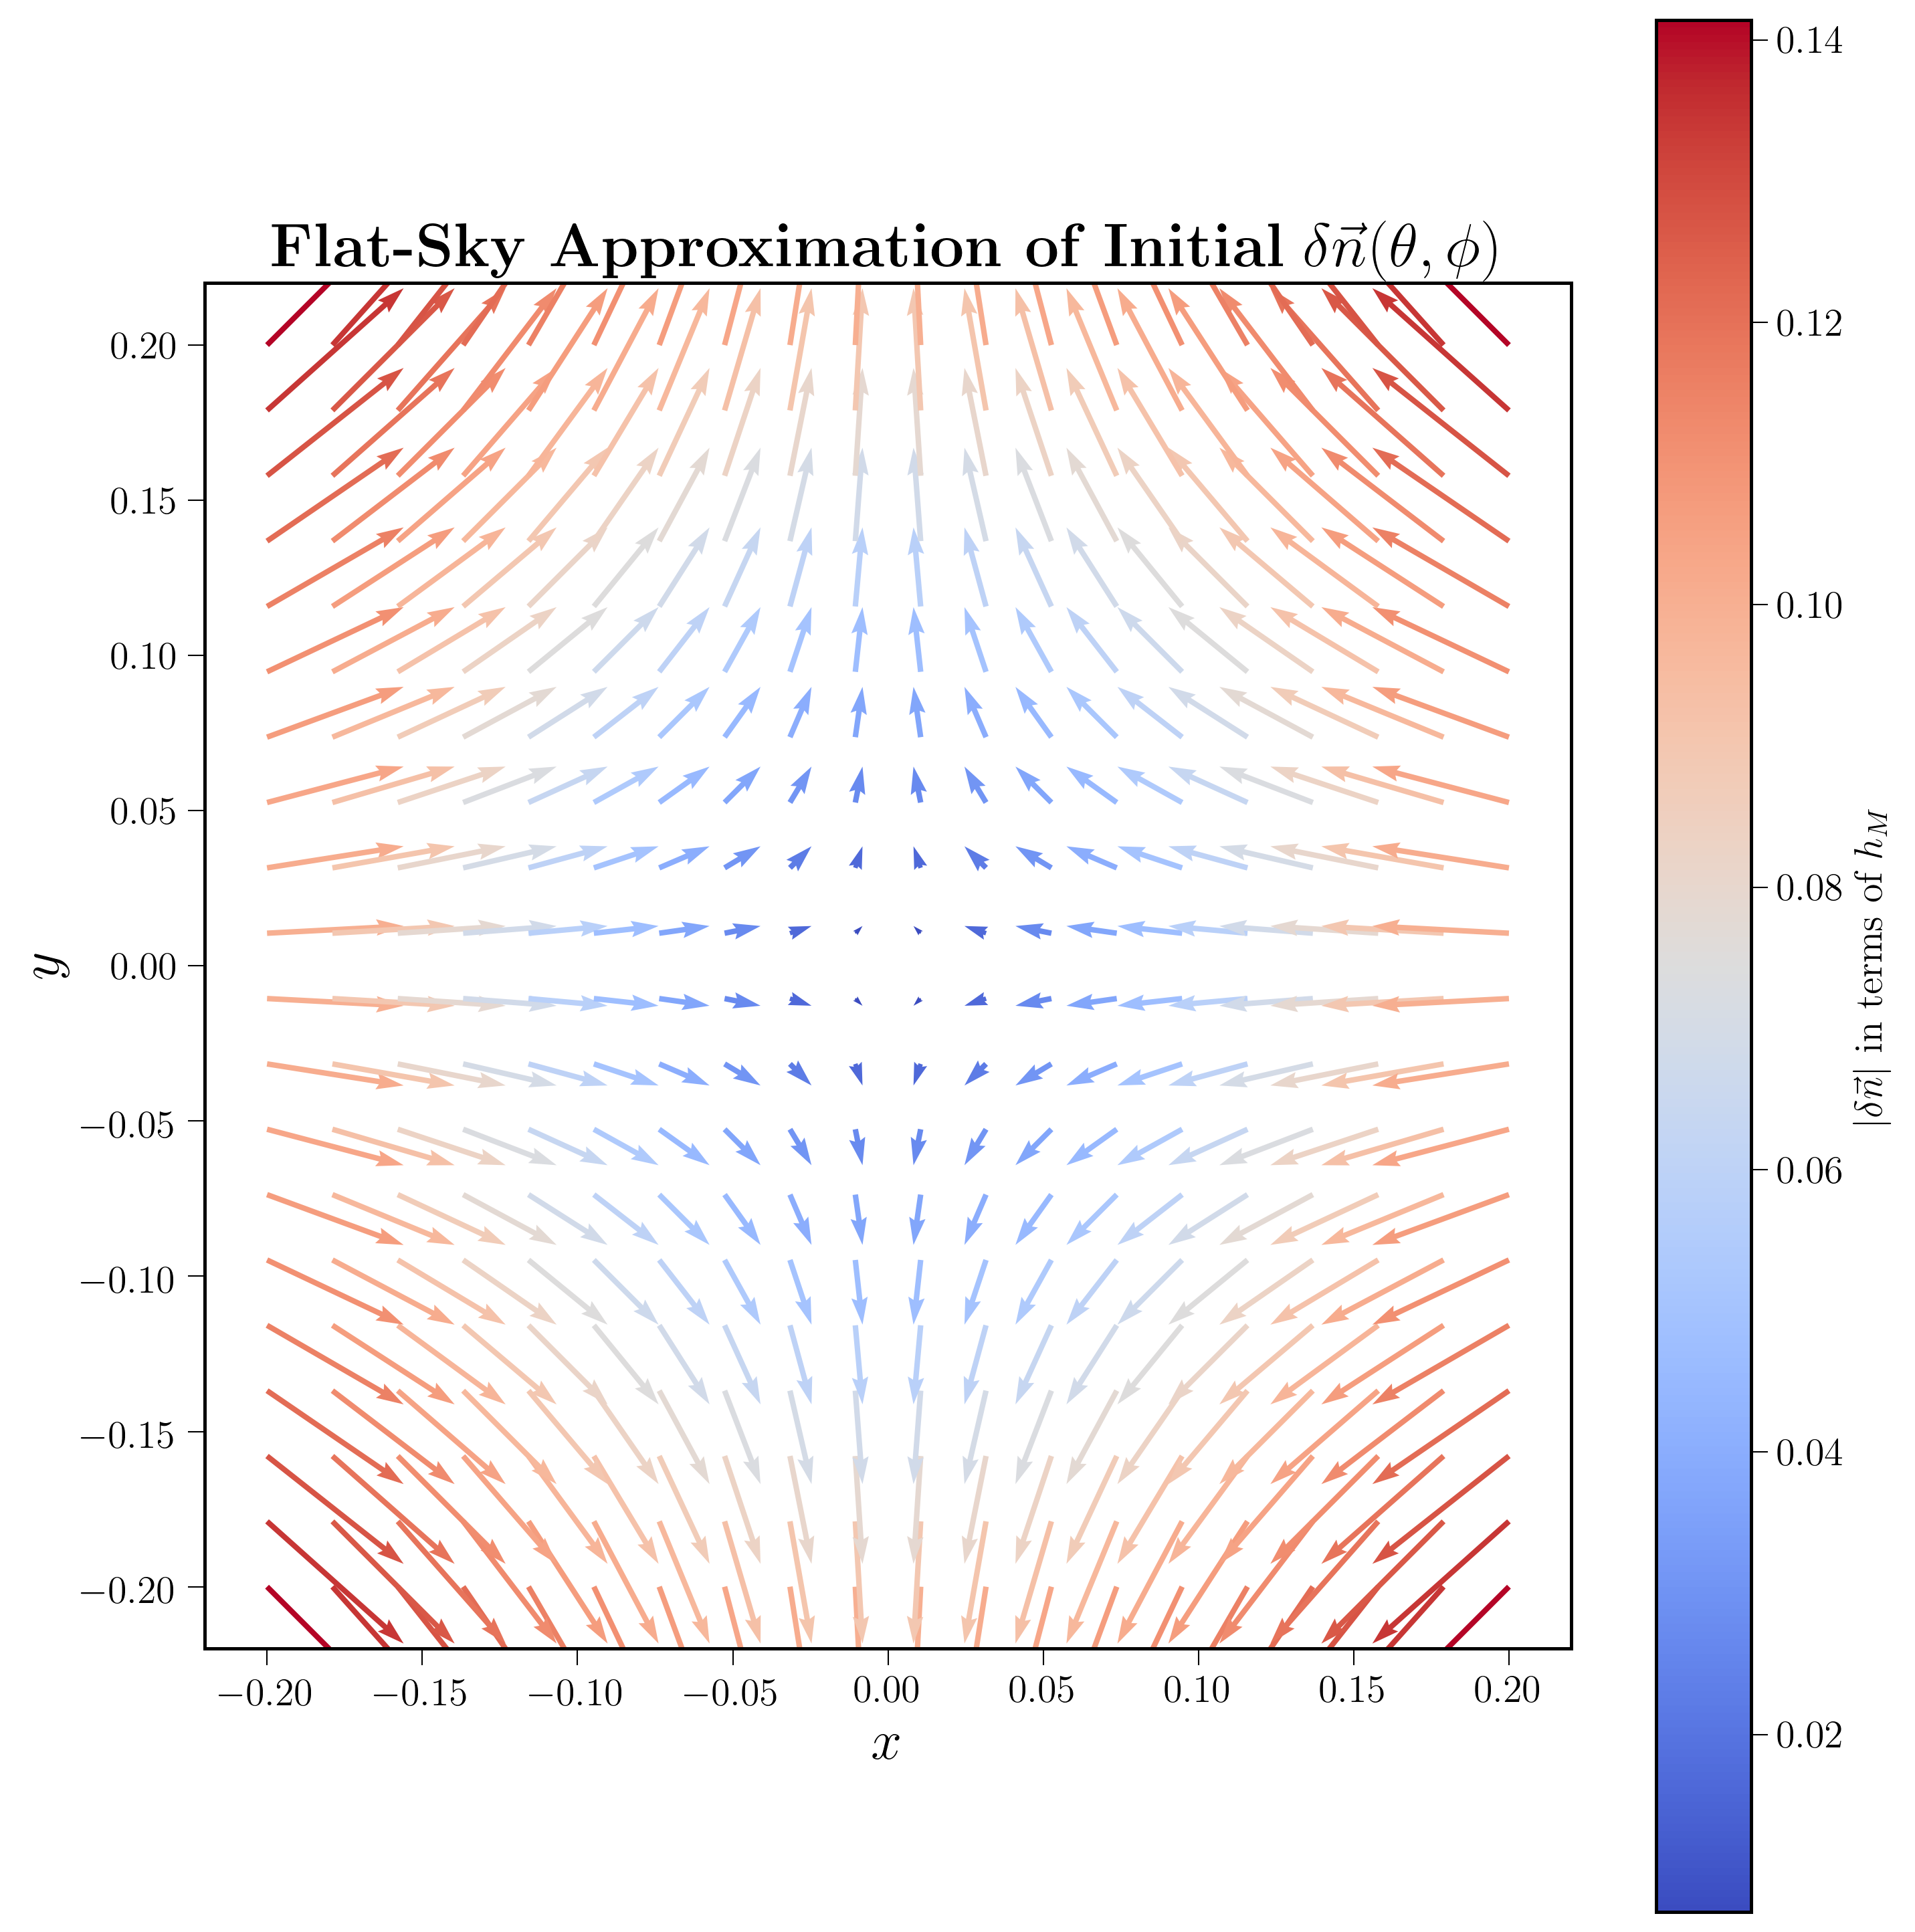

In [5]:
# Plotting initial angular deflections from Madison's paper 

r_max = 0.2
N = 20  # lower resolution for clarity
x = np.linspace(-r_max, r_max, N)
y = np.linspace(-r_max, r_max, N)
X, Y = np.meshgrid(x, y)

# Polar coordinates
theta = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

# Compute components
coeff = -0.25 * theta
dn_x = coeff * (2 * np.cos(2*phi) * np.cos(phi) + 2 * np.sin(2*phi) * np.sin(phi))
dn_y = coeff * (2 * np.cos(2*phi) * np.sin(phi) - 2 * np.sin(2*phi) * np.cos(phi))
magnitude = np.sqrt(dn_x**2 + dn_y**2)

# Plot
fig, ax = plt.subplots()
q = ax.quiver(X, Y, dn_x, dn_y, magnitude, cmap='coolwarm', scale=1, width=0.004)
cb = fig.colorbar(q, ax=ax, label=r'$|\delta \vec{n}|$ in terms of $h_M$')
ax.set_xlabel(r'$x$', fontsize=20)
ax.set_ylabel(r'$y$', fontsize=20)
ax.set_title(r'\textbf{Flat-Sky Approximation of Initial} $\delta \vec{n}(\theta, \phi)$', fontsize=22)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

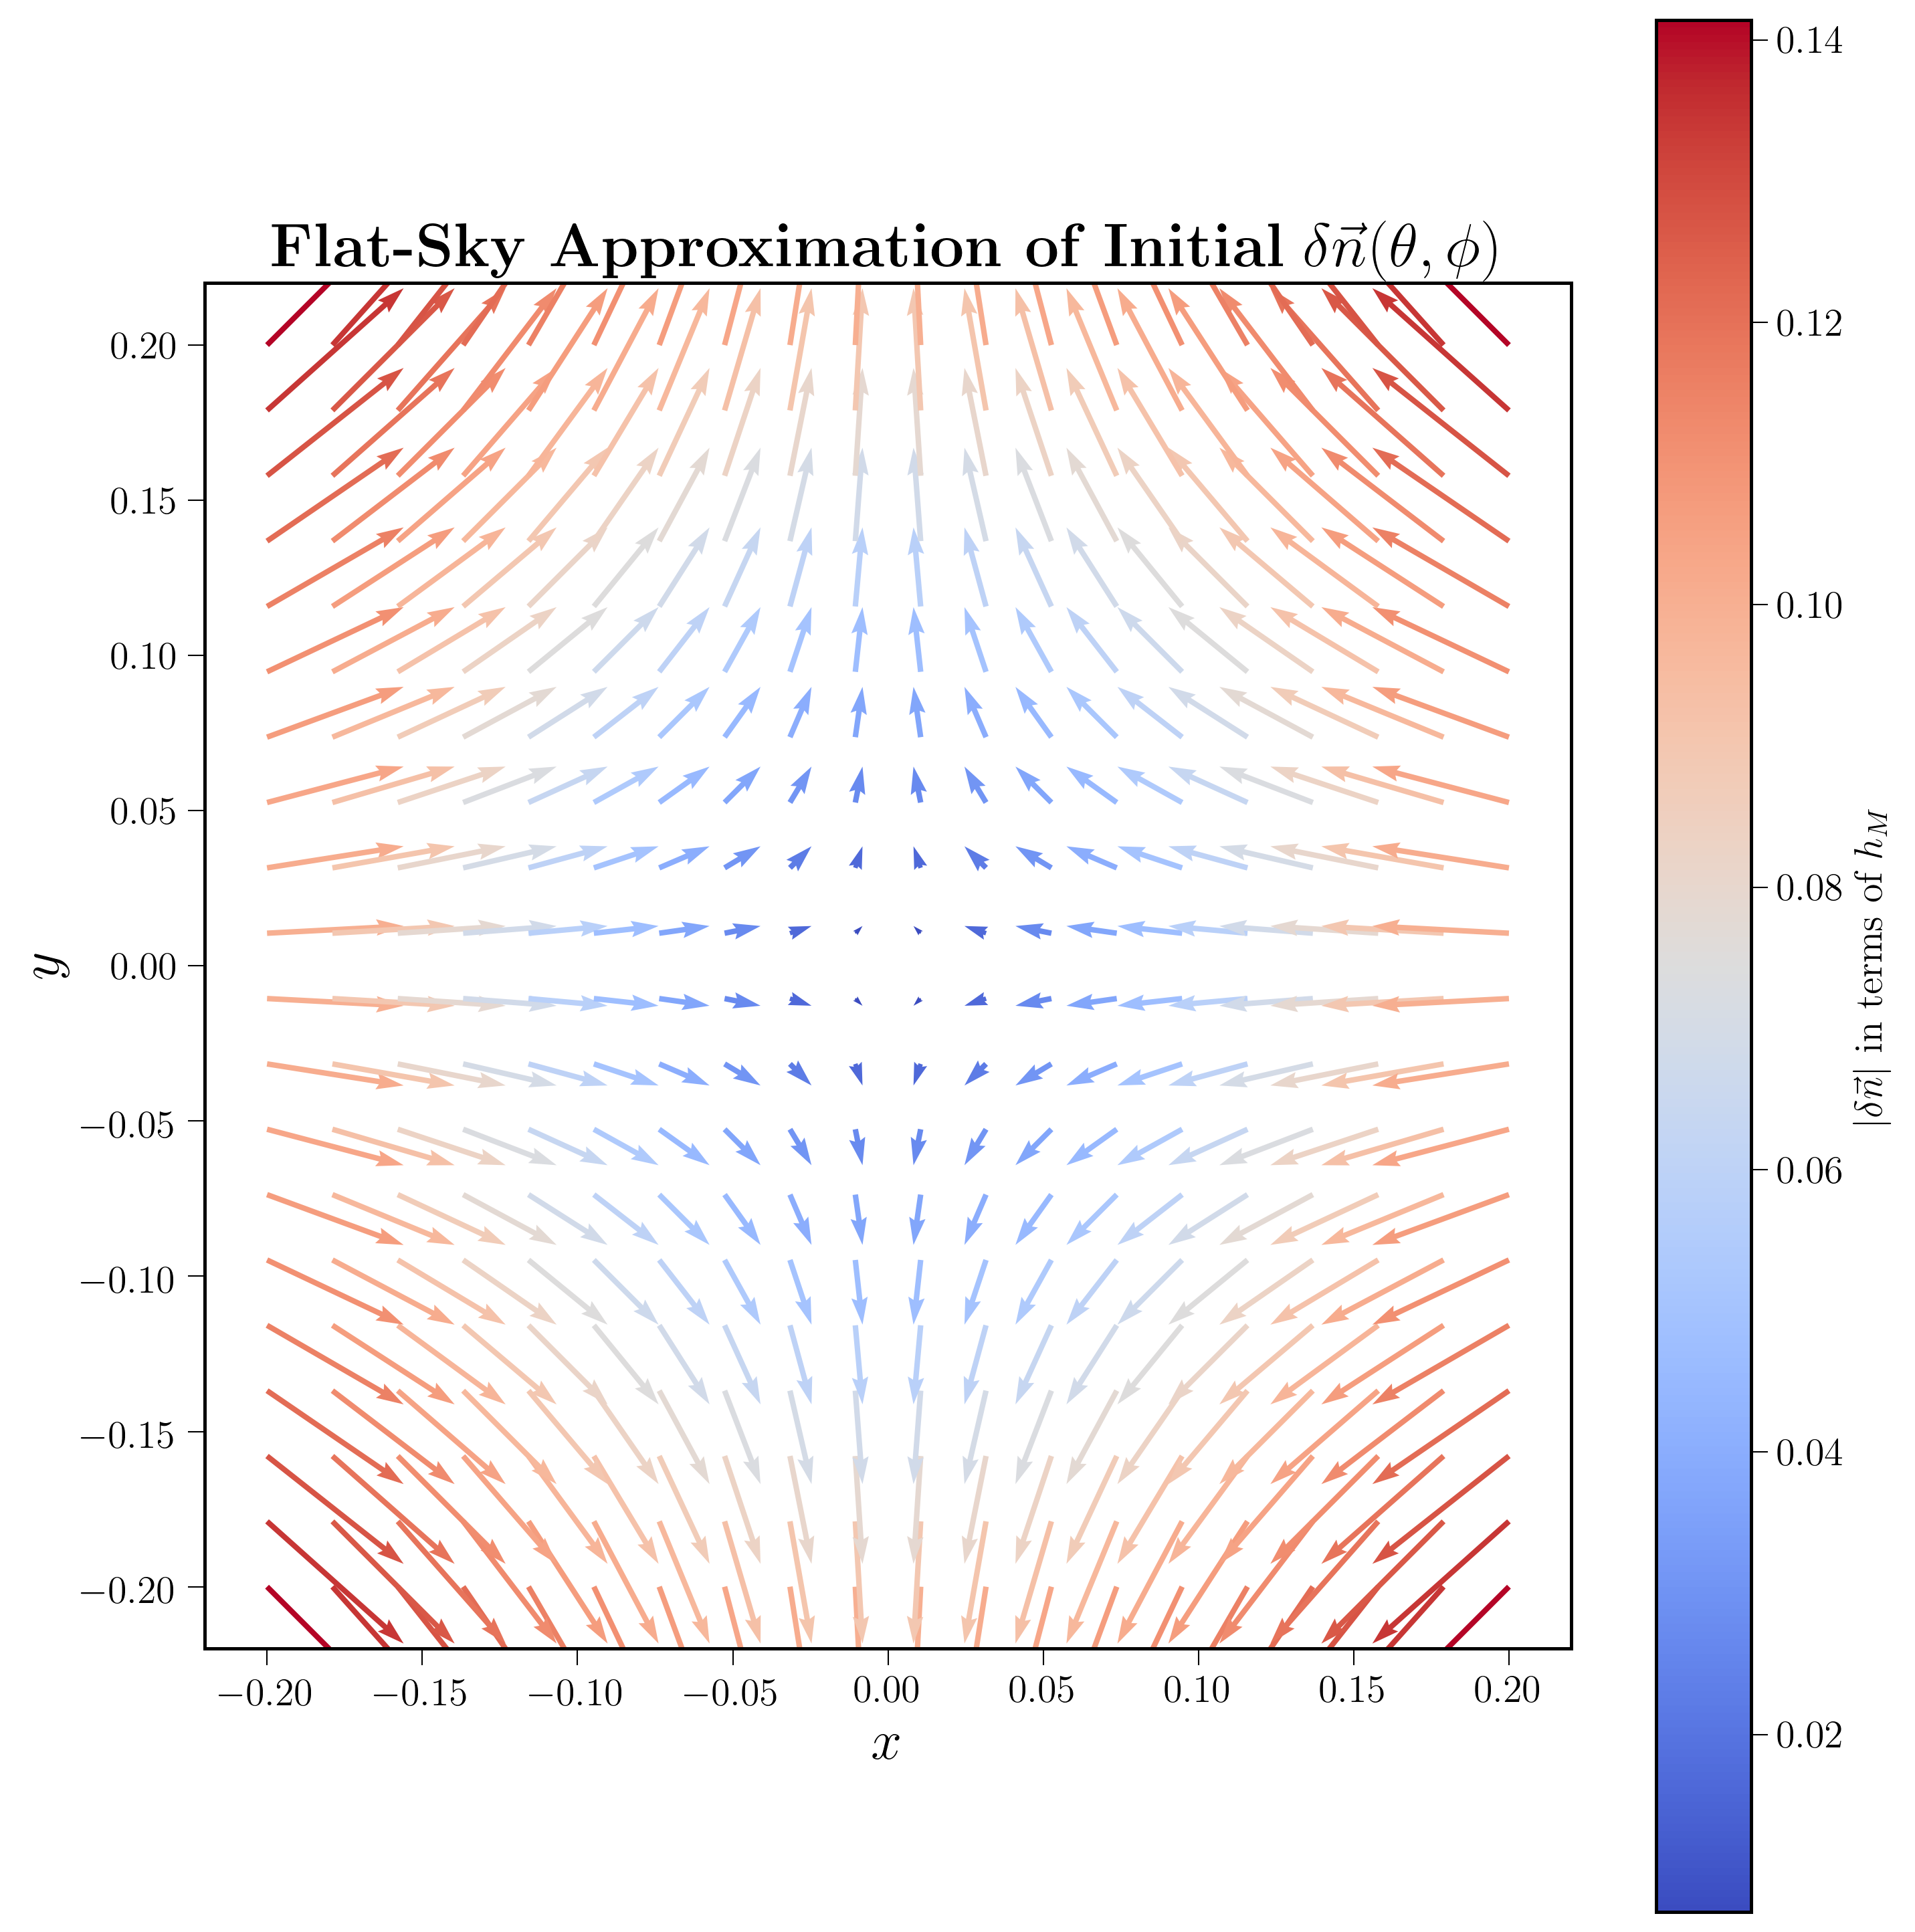

In [6]:
# Plotting time-varying angular deflections from Madison's paper 
# Not taking into account the Madison's cutoff angle, above which z=0
# This plots the deflections at one time given by b = ct/d. d is the distance to the light source

r_max = 0.2
N = 20  # lower resolution for clarity
x = np.linspace(-r_max, r_max, N)
y = np.linspace(-r_max, r_max, N)
X, Y = np.meshgrid(x, y)

# Polar coordinates
theta = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

b = 0

# Compute components
coeff = -0.25 * theta
dn_x = coeff * ((2 * np.cos(2*phi) - (b/(1+np.cos(theta)))*(1+np.cos(theta)) * (2 * np.cos(2*phi))) * np.cos(phi) - (-2 * np.sin(2 * phi) - (b/(1+np.cos(theta)))*4*np.sin(2 * phi)) * np.sin(phi))
dn_y = coeff * ((2 * np.cos(2*phi) - (b/(1+np.cos(theta)))*(1+np.cos(theta)) * (2 * np.cos(2*phi))) * np.sin(phi) + (-2 * np.sin(2*phi) - (b/(1+np.cos(theta)))*4 * np.sin(2 * phi)) * np.cos(phi))
magnitude = np.sqrt(dn_x**2 + dn_y**2)
                
# Plot
fig, ax = plt.subplots()
q = ax.quiver(X, Y, dn_x, dn_y, magnitude, cmap='coolwarm', scale=1, width=0.004)
cb = fig.colorbar(q, ax=ax, label=r'$|\delta \vec{n}|$ in terms of $h_M$')
ax.set_xlabel(r'$x$', fontsize=20)
ax.set_ylabel(r'$y$', fontsize=20)
ax.set_title(r'\textbf{Flat-Sky Approximation of Initial} $\delta \vec{n}(\theta, \phi)$', fontsize=22)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

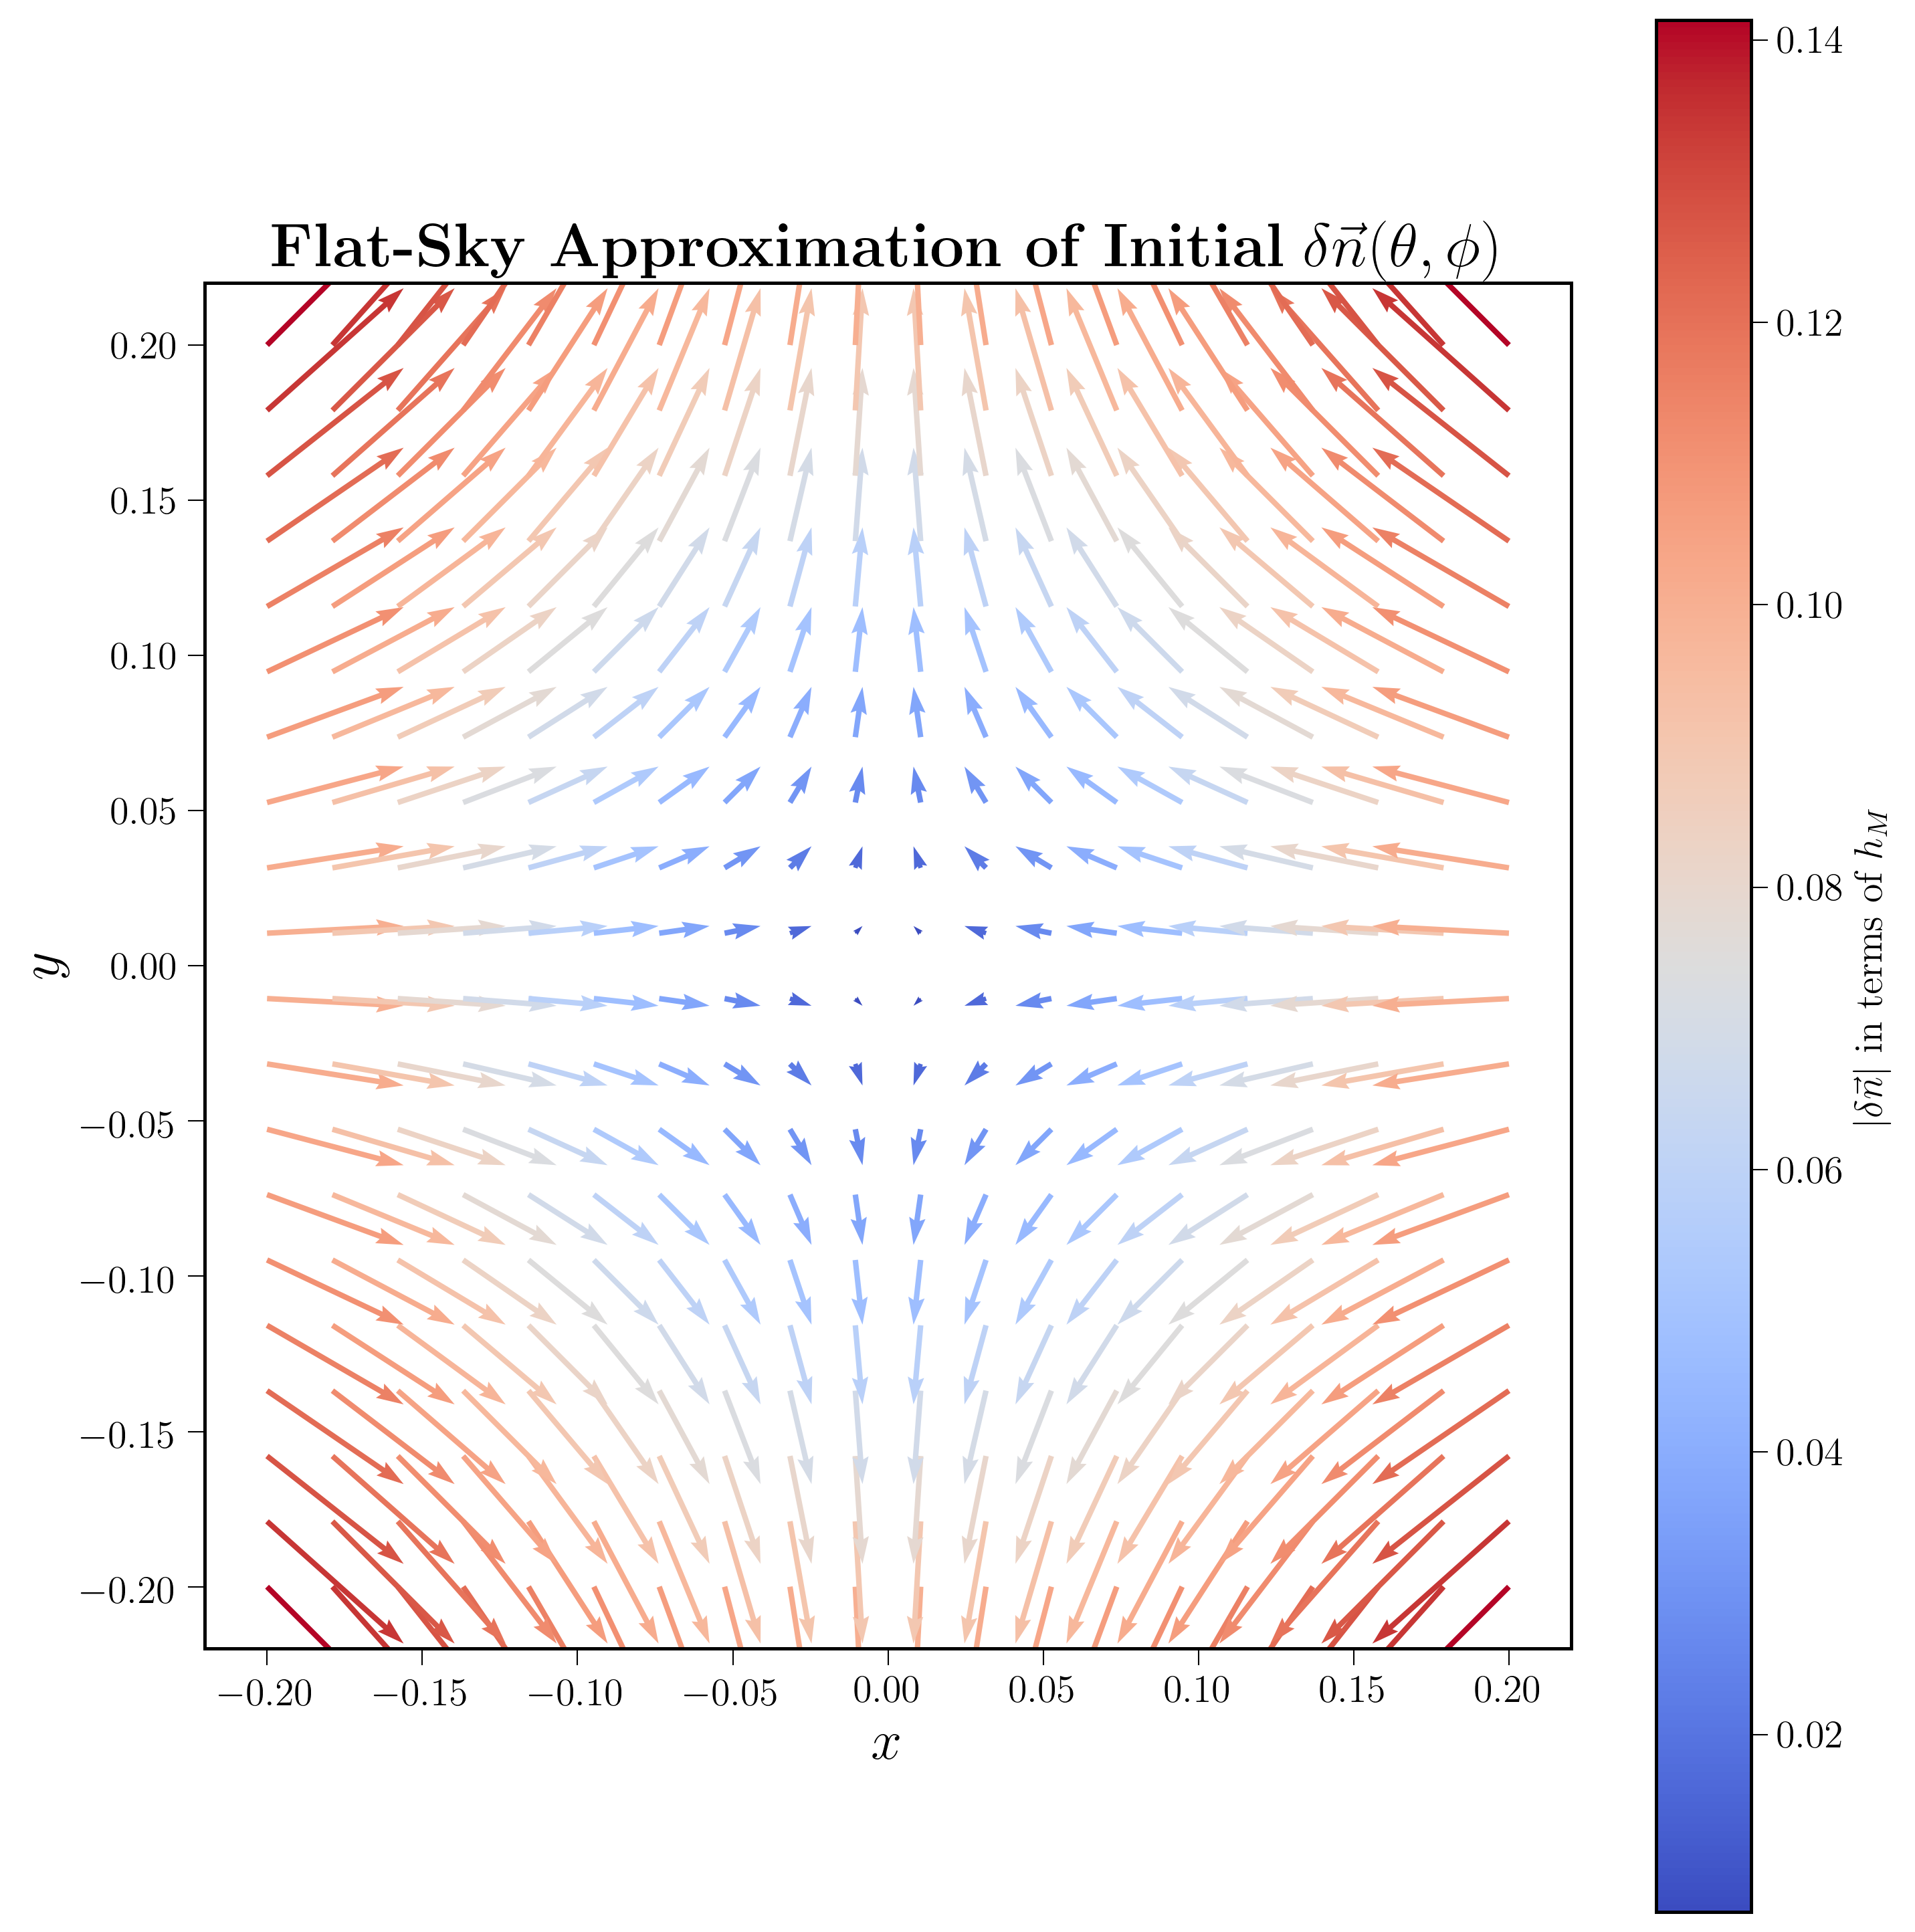

In [7]:
# automatic animation for deflections

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Set up the grid
r_max = 0.2
N = 20
x = np.linspace(-r_max, r_max, N)
y = np.linspace(-r_max, r_max, N)
X, Y = np.meshgrid(x, y)
theta = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

# Function to compute dn_x, dn_y, and magnitude given b = ct/d
def compute_vectors(b):
    coeff = -0.25 * theta
    common_factor = (2 * np.cos(2*phi) - (b / (1 + np.cos(theta))) * (1 + np.cos(theta)) * (2 * np.cos(2*phi)))
    sin_term = (-2 * np.sin(2 * phi) - (b / (1 + np.cos(theta))) * 4 * np.sin(2 * phi))
    
    dn_x = coeff * (common_factor * np.cos(phi) - sin_term * np.sin(phi))
    dn_y = coeff * (common_factor * np.sin(phi) + sin_term * np.cos(phi))
    magnitude = np.sqrt(dn_x**2 + dn_y**2)
    return dn_x, dn_y, magnitude

# Initialize the plot
fig, ax = plt.subplots()
dn_x, dn_y, magnitude = compute_vectors(0)
q = ax.quiver(X, Y, dn_x, dn_y, magnitude, cmap='coolwarm', scale=1, width=0.004)
cb = fig.colorbar(q, ax=ax, label=r'$|\delta \vec{n}|$ in terms of $h_M$')

ax.set_xlabel(r'$x$', fontsize=20)
ax.set_ylabel(r'$y$', fontsize=20)
ax.set_title(r'\textbf{Flat-Sky Approximation of Initial} $\delta \vec{n}(\theta, \phi)$', fontsize=22)
ax.set_aspect('equal')
plt.tight_layout()

# Animation update function
def animate(frame):
    b = frame
    dn_x, dn_y, magnitude = compute_vectors(b)
    q.set_UVC(dn_x, dn_y, magnitude)
    return q,

# b values from 0 to 2 over 100 frames
b_vals = np.linspace(0, 2, 100)
anim = FuncAnimation(fig, animate, frames=b_vals, interval=100, blit=False)

plt.show()

